In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
# 載入所有降雨數據
designrain_all = np.load(os.path.dirname(os.getcwd())+'/rainfall/training_raindata.npy').tolist()
num_rainfalls = 30  # 總共1000

realrain_all = np.load(os.path.dirname(os.getcwd())+'/rainfall\\real_raindata.npy').tolist()

# 擴大（*5）
realrain_all = [
    [
        [time, str(float(rain) * 5)]
        for time, rain in event
    ]
    for event in realrain_all
]

In [3]:
start_idx = 50
one_step = 5 # 300s = 5min

In [4]:
n_pick = 4      # 要選出的design場數

In [5]:
peak_values = []
for i in range(num_rainfalls):
    i += start_idx
    rain_event = designrain_all[i]
    event_rain_values = [float(v[1]) for v in rain_event]  # 取強度列
    peak = max(event_rain_values) if len(event_rain_values) > 0 else 0.0
    peak_values.append(peak)

peak_values = np.array(peak_values)
sorted_indices = np.argsort(peak_values)  # 從小到大

# 等梯度選樣（近似 0%, 20%, 40%, 60%, 80%, 100% 百分位）
if n_pick == 1:
    chosen_local_idx = [len(sorted_indices)//2]
else:
    chosen_local_idx = np.linspace(0, len(sorted_indices)-1, n_pick).round().astype(int)

designrain_indices = sorted_indices[chosen_local_idx]  # 0~49 的局部索引
designrain_events = [start_idx + int(i) for i in designrain_indices] # 只有这个是原始索引，其他都是局部

print("Selected events by peak gradient:", designrain_events)
print("Their peak intensities:", [float(peak_values[i]) for i in designrain_indices])

Selected events by peak gradient: [70, 64, 67, 51]
Their peak intensities: [81.38139521835302, 136.99042512240572, 161.3605100623962, 228.33281936149768]


In [6]:
designrain={}
realrain = {}
for i in range(4):
    designrain[i]=[]
    realrain[i]=[]
    design_rain_index = designrain_events[i]
    for j in range(len(designrain_all[design_rain_index])):
        designrain[i].append(float(designrain_all[design_rain_index][j][1]))
    for j in range(len(realrain_all[i])):
        realrain[i].append(float(realrain_all[i][j][1]))

# 选出部分training data和rr data作图

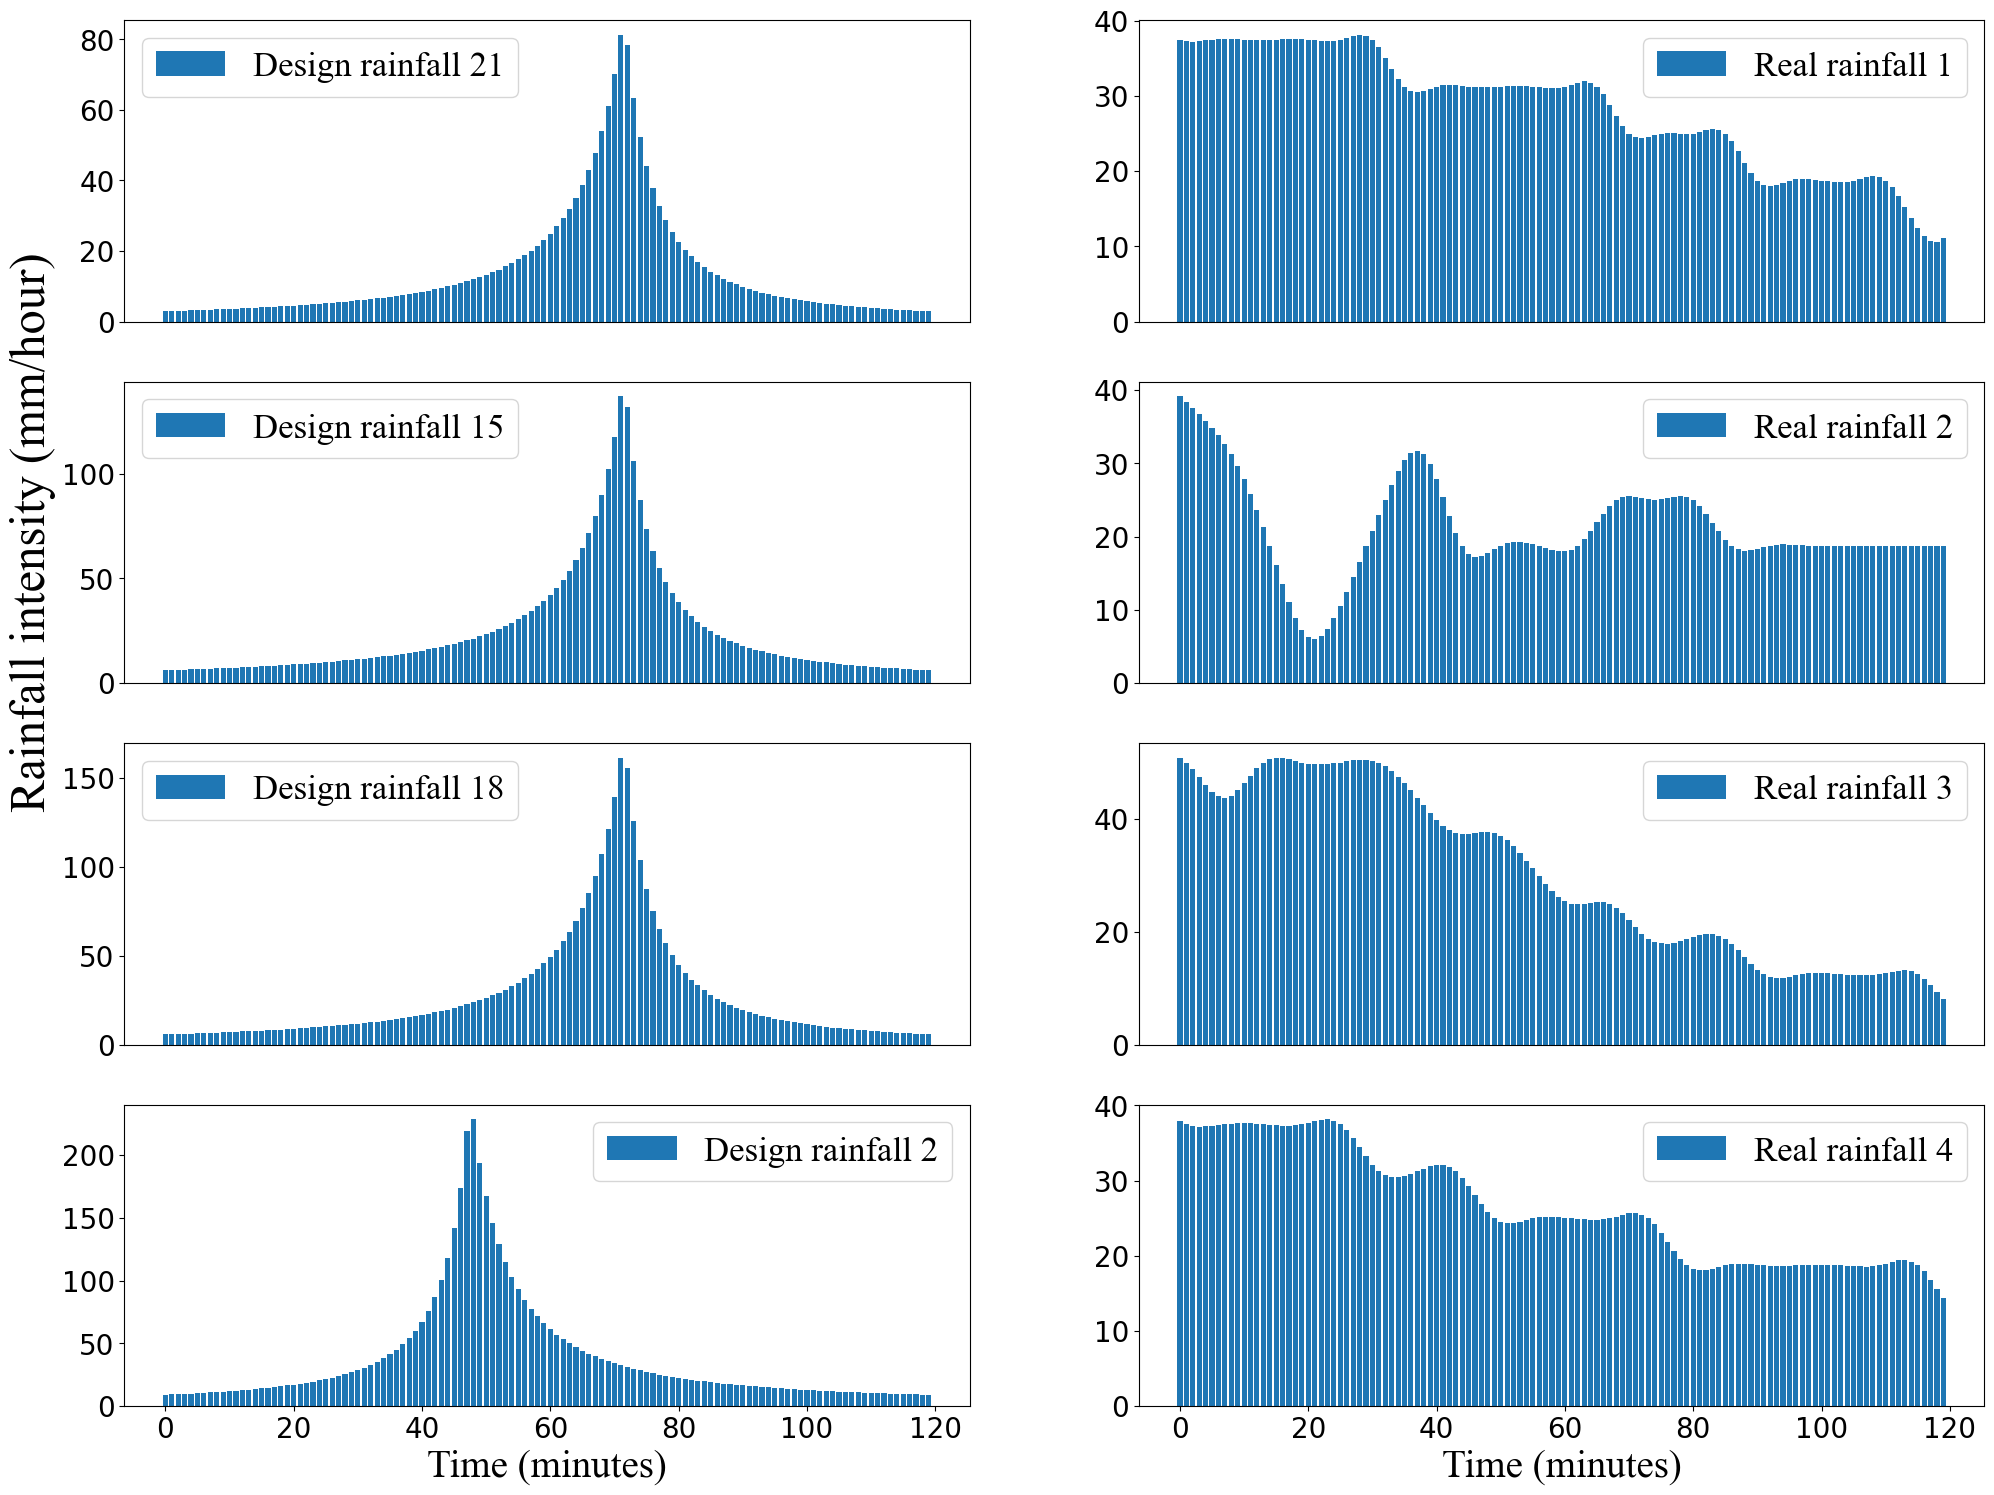

In [7]:
fontx = {
        'fontsize':28,
        'color':'k',
        'family':'Times New Roman',
}
fonty = {
        'fontsize':35,
        'color':'k',
        'family':'Times New Roman', 
}
legend_font = {
        'size':25,
        'family':'Times New Roman', 
}

fig,ax = plt.subplots(4,2,figsize=(24,18))
for i in range(4):
    ax[i,0].bar(np.arange(len(designrain[i])),designrain[i],label='Design rainfall '+str(designrain_indices[i]+1))
    ax[i,1].bar(np.arange(len(realrain[i])),realrain[i],label='Real rainfall '+str(i+1))
    for j in range(2):
        ax[i,j].legend(prop=legend_font)
        ax[i,j].tick_params(axis='y',labelsize=20)
        ax[i,j].tick_params(axis='x',labelsize=20)
    if i < 3:
        ax[i,0].set_xticks([])
        ax[i,1].set_xticks([])
    else:
        ax[i,0].set_xlabel('Time (minutes)',fontdict=fontx)
        ax[i,1].set_xlabel('Time (minutes)',fontdict=fontx)

    if i == 1:
        ax[i,0].set_ylabel('Rainfall intensity (mm/hour)',fontdict=fonty)

plt.savefig(os.path.dirname(os.getcwd())+'\\fig_rainfall.png',dpi=200,bbox_inches='tight')
